In [21]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [ ]:
class AgentState(TypedDict):
  player_name: str
  guesses: List[int]
  attempts: int
  lower_bound: int
  upper_bound: int
  answer:int
  max_limit: int

In [ ]:
def start_node(state: AgentState)->dict:
  return {
    "player_name": state['player_name'],
    "answer": random.randint(state['lower_bound'],state['upper_bound']),
    "attempts":0,
    "max_limit":7,
    "guesses": []
  }
  # second_graph.add_node("router", lambda state: {})
def make_guess(state: AgentState)->dict:
  new_guess = random.randint(state["lower_bound"], state["upper_bound"])
  return {
    "attempts": state['attempts'] + 1,
    "guesses" :  state["guesses"] + [new_guess]
  }

def guessing_condition(state: AgentState)->str:
  print("Entering Loop", state['attempts'])
  if state['attempts'] > state['max_limit']:
    print("Max Attempt")
    return 'exit'
  elif state['answer'] == state['guesses'][-1]:
    print("Corrent Answer!")
    return 'exit'
  else:
    return 'loop'


In [27]:
graph = StateGraph(AgentState)

graph.add_node("start_node", start_node)
graph.add_node("make_guess", make_guess)

graph.add_edge("start_node", "make_guess")

graph.add_conditional_edges(
  "make_guess",
  guessing_condition,
  {
    "loop": "make_guess",
    "exit": END
  }
)

graph.set_entry_point("start_node")
app = graph.compile()

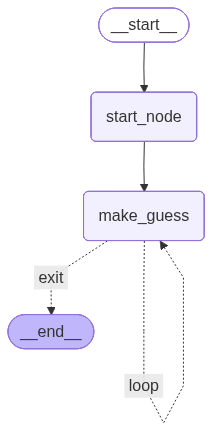

In [28]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
result = app.invoke({
    "player_name": "Wei",
    "lower_bound": 1,
    "upper_bound": 10
})

print(result)

Entering Loop 1
Entering Loop 2
Entering Loop 3
Entering Loop 4
Corrent Answer!
{'player_name': 'Wei', 'guesses': [3, 7, 7, 4], 'attempts': 4, 'lower_bound': 1, 'upper_bound': 10, 'answer': 4, 'max_limit': 7, 'condition': 'Not right'}
